# Data Scientist Project - Recipe Site Traffic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# import libraries for ML
from scipy.stats import yeojohnson
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [2]:
# Load the dataset
df = pd.read_csv('recipe_site_traffic_2212.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB
None
   recipe  calories  carbohydrate  ...   category  servings high_traffic
0       1       NaN           NaN  ...       Pork         6         High
1       2     35.48         38.56  ...     Potato         4         High
2       3    914.28         42.68  ...  Breakfast         1          NaN
3       4     97.03         30.56  ...  Beverages         4         High
4       5     27.05          1.85

## Data Validation and Cleaning
This data set has 947 rows, 8 columns. I have validated all variables and performed data cleaning:
- recipe: unique id of recipe. Cleaning needed.
- calories: numeric values without missing values. No cleaning needed.
- carbohydrate: numeric values without missing values. No cleaning needed.
- sugar: numeric values without missing values. No cleaning needed.
- protein: numeric values without missing values. No cleaning needed.
- category: 10 categories with data inconsistency. Cleaning needed
- servings: numeric values with missing values. Cleaning needed.
- high_traffic: 2 categories. Cleaning needed.

In [3]:
# Display the count of each unique value in the 'high_traffic' column to check class distribution
print(df['high_traffic'].value_counts())

High    574
Name: high_traffic, dtype: int64


In [4]:
# Convert the 'high_traffic' column to boolean: True if value is "High", otherwise False
df['high_traffic'] = np.where(df['high_traffic'] == "High", True, False)
print(df['high_traffic'].value_counts())

True     574
False    373
Name: high_traffic, dtype: int64


In [5]:
# Display the count of each unique value in the 'servings' column to check for distribution and missing values
print(df['servings'].value_counts())

4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: servings, dtype: int64


In [6]:
# Replace some entries in servings column with just the numeric value
df['servings'] = df['servings'].str.replace(" as a snack", "")
print(df['servings'].value_counts())
# Convert it to integer
df['servings'] = df['servings'].astype('int')

4    391
6    198
2    183
1    175
Name: servings, dtype: int64


In [7]:
# Display the count of each unique value in the 'category' column to check for data consistency and distribution
print(df['category'].value_counts())

Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: category, dtype: int64


In [8]:
# Replace some entries in category column with just the numeric value
df['category'] = df['category'].str.replace(" Breast", "")
print(df['category'].value_counts())
# Convert it to category
df['category'] = df['category'].astype('category')

Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: category, dtype: int64


In [9]:
# Display concise summary of the DataFrame, including column names, non-null counts, and data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   recipe        947 non-null    int64   
 1   calories      895 non-null    float64 
 2   carbohydrate  895 non-null    float64 
 3   sugar         895 non-null    float64 
 4   protein       895 non-null    float64 
 5   category      947 non-null    category
 6   servings      947 non-null    int64   
 7   high_traffic  947 non-null    bool    
dtypes: bool(1), category(1), float64(4), int64(2)
memory usage: 46.7 KB
None


In [10]:
# # Display the number of missing (NaN) values in each column of the DataFrame
print(df.isna().sum())

recipe           0
calories        52
carbohydrate    52
sugar           52
protein         52
category         0
servings         0
high_traffic     0
dtype: int64


In [11]:
# Remove all rows with missing values from the DataFrame and reset the index
df = df.dropna().reset_index(drop=True)
print(df.isna().sum())
print(df.info())

recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   recipe        895 non-null    int64   
 1   calories      895 non-null    float64 
 2   carbohydrate  895 non-null    float64 
 3   sugar         895 non-null    float64 
 4   protein       895 non-null    float64 
 5   category      895 non-null    category
 6   servings      895 non-null    int64   
 7   high_traffic  895 non-null    bool    
dtypes: bool(1), category(1), float64(4), int64(2)
memory usage: 44.2 KB
None


In [12]:
# Display summary statistics for the numerical columns in the DataFrame
df.describe()

,recipe,calories,carbohydrate,sugar,protein,servings
count,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000
mean,473.652514,435.939196,35.069676,9.046547,24.149296,3.458101
std,272.763283,453.020997,43.949032,14.679176,36.369739,1.735979
min,2.000000,0.140000,0.030000,0.010000,0.000000,1.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000,2.000000
50%,475.000000,288.550000,21.480000,4.550000,10.800000,4.000000
75%,708.500000,597.650000,44.965000,9.800000,30.200000,4.000000
max,947.000000,3633.160000,530.420000,148.750000,363.360000,6.000000


## Exploratory Analysis

Now that the data has been cleaned and missing values have been removed, we can begin exploring the dataset to uncover patterns and insights. This section will include visualizations and statistical summaries to better understand the distribution of features, relationships between variables, and potential differences across categories. Key questions to consider include:

- What are the distributions of the main numerical features?
- Are there any correlations between features?
- How do the features differ across the different categories?
- Are there any outliers or unusual patterns in the data?

Let's proceed with some visual and statistical exploratory analysis to address these questions.

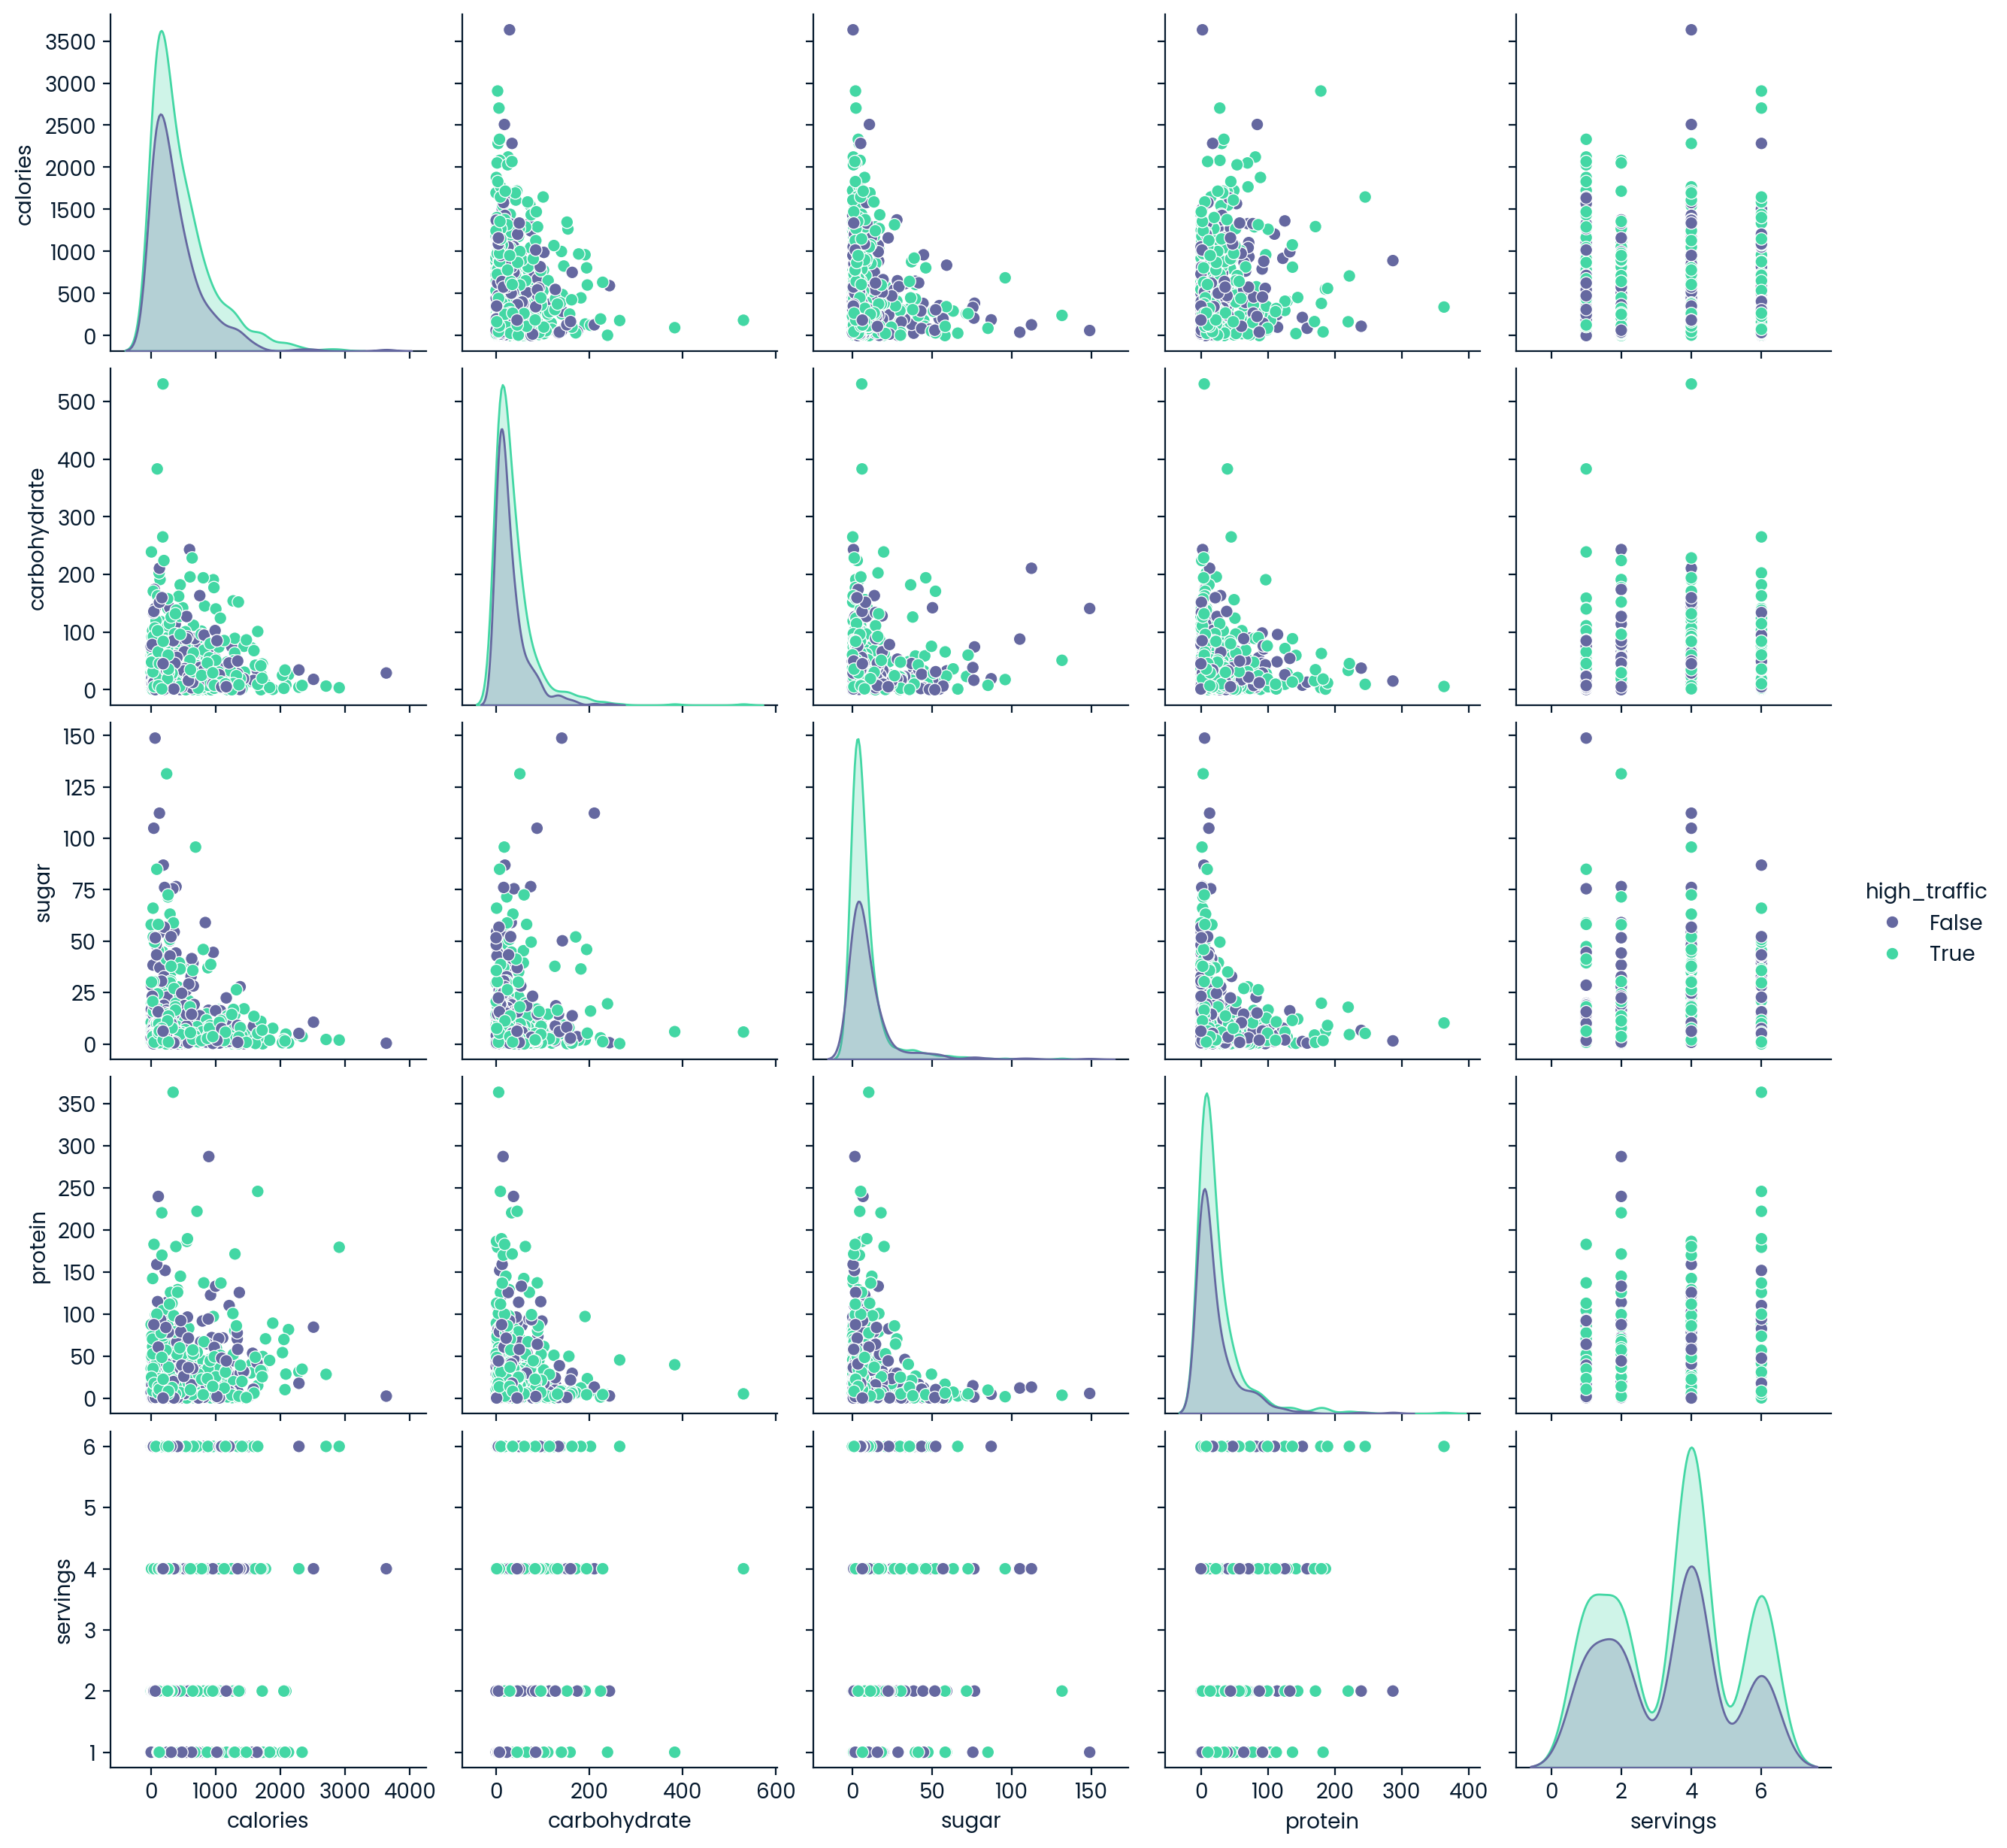

In [13]:
# Pairplot to see the correlations between these columns:
filtered_columns = ['calories', 'carbohydrate', 'sugar', 'protein', 'category', 'servings', 'high_traffic']
sns.pairplot(df[filtered_columns], hue='high_traffic')
plt.show()

### Visualizing Relationships Between Variables

Pairplot was used to examine relationships between variables. The plots show weak correlations, suggesting that no strong linear relationships exist between the features.

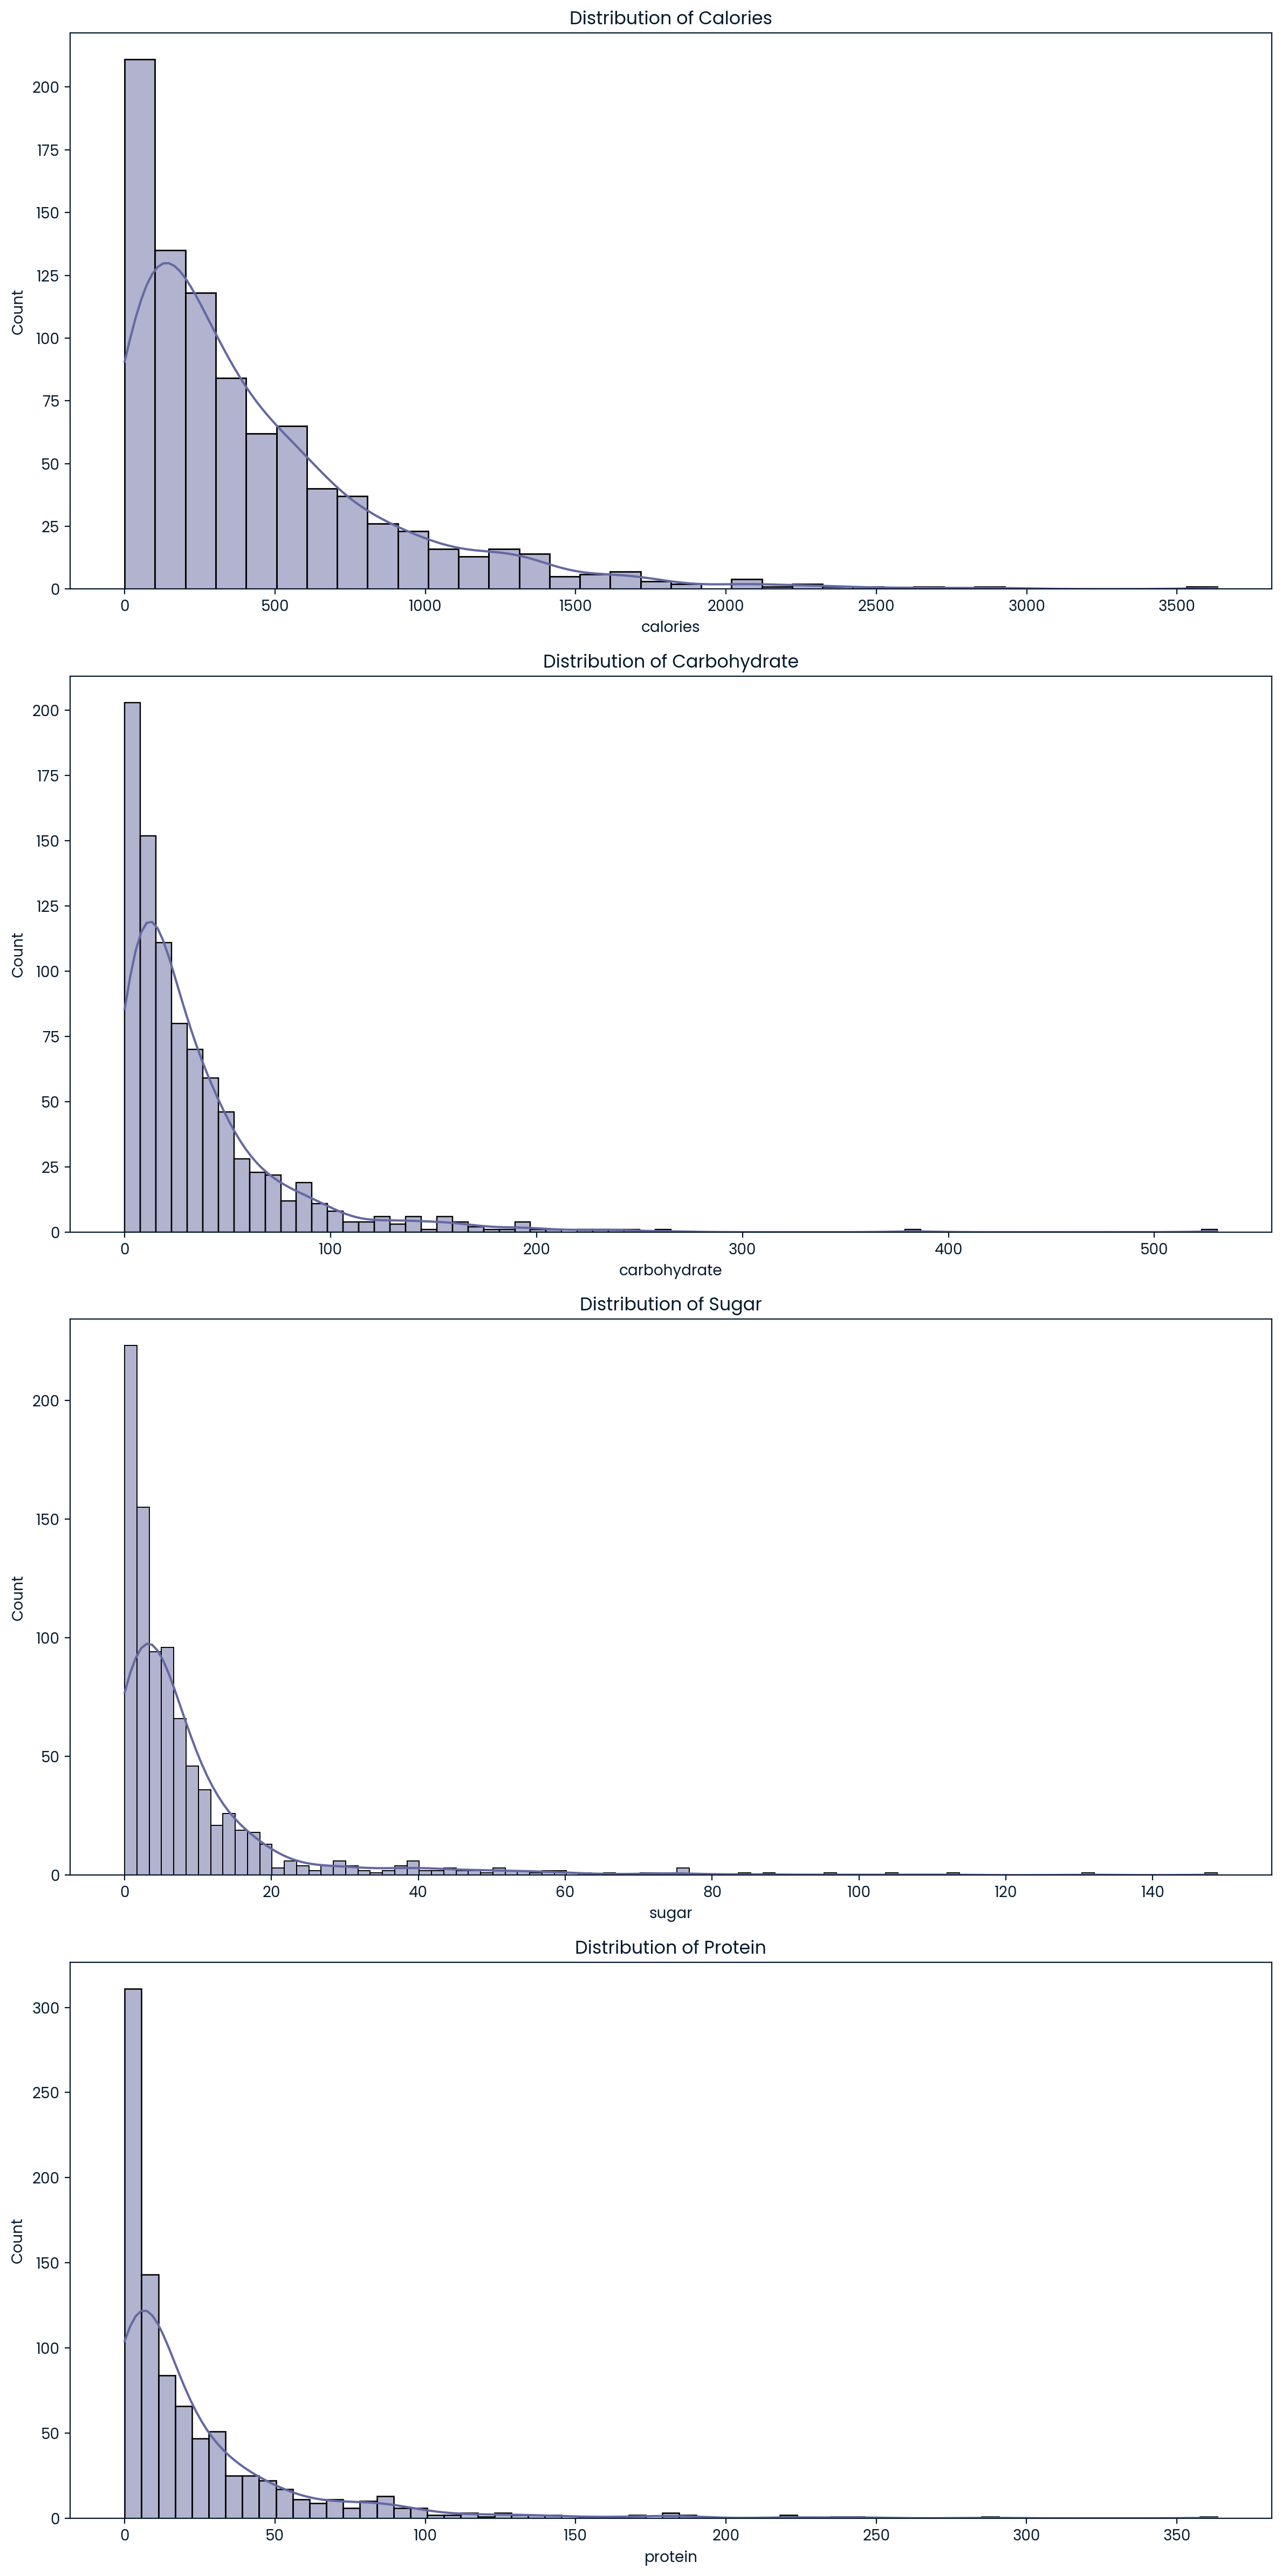

In [14]:
# Histograms to visualize the distribution of calories
# Select only float columns
numerical_columns = df.select_dtypes(include='float').columns
num_rows = len(numerical_columns)
fig, axes = plt.subplots(num_rows, 1, figsize=(12, 6 * num_rows))
for i, column in enumerate(numerical_columns):
    ax = axes[i] if num_rows > 1 else axes
    sns.histplot(data=df, x=column, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column.capitalize()}")
plt.tight_layout()

### Histogram Analysis of Nutritional Features

The histograms clearly show that most recipes have low calorie, carbohydrate, sugar, and protein values. All distributions are right-skewed, meaning the majority of data points are clustered at the lower end, with a few recipes containing very high values. This confirms that extreme outliers exist in the dataset. To further examine these distributions, I will use box plots for a clearer view of spread and potential outliers.

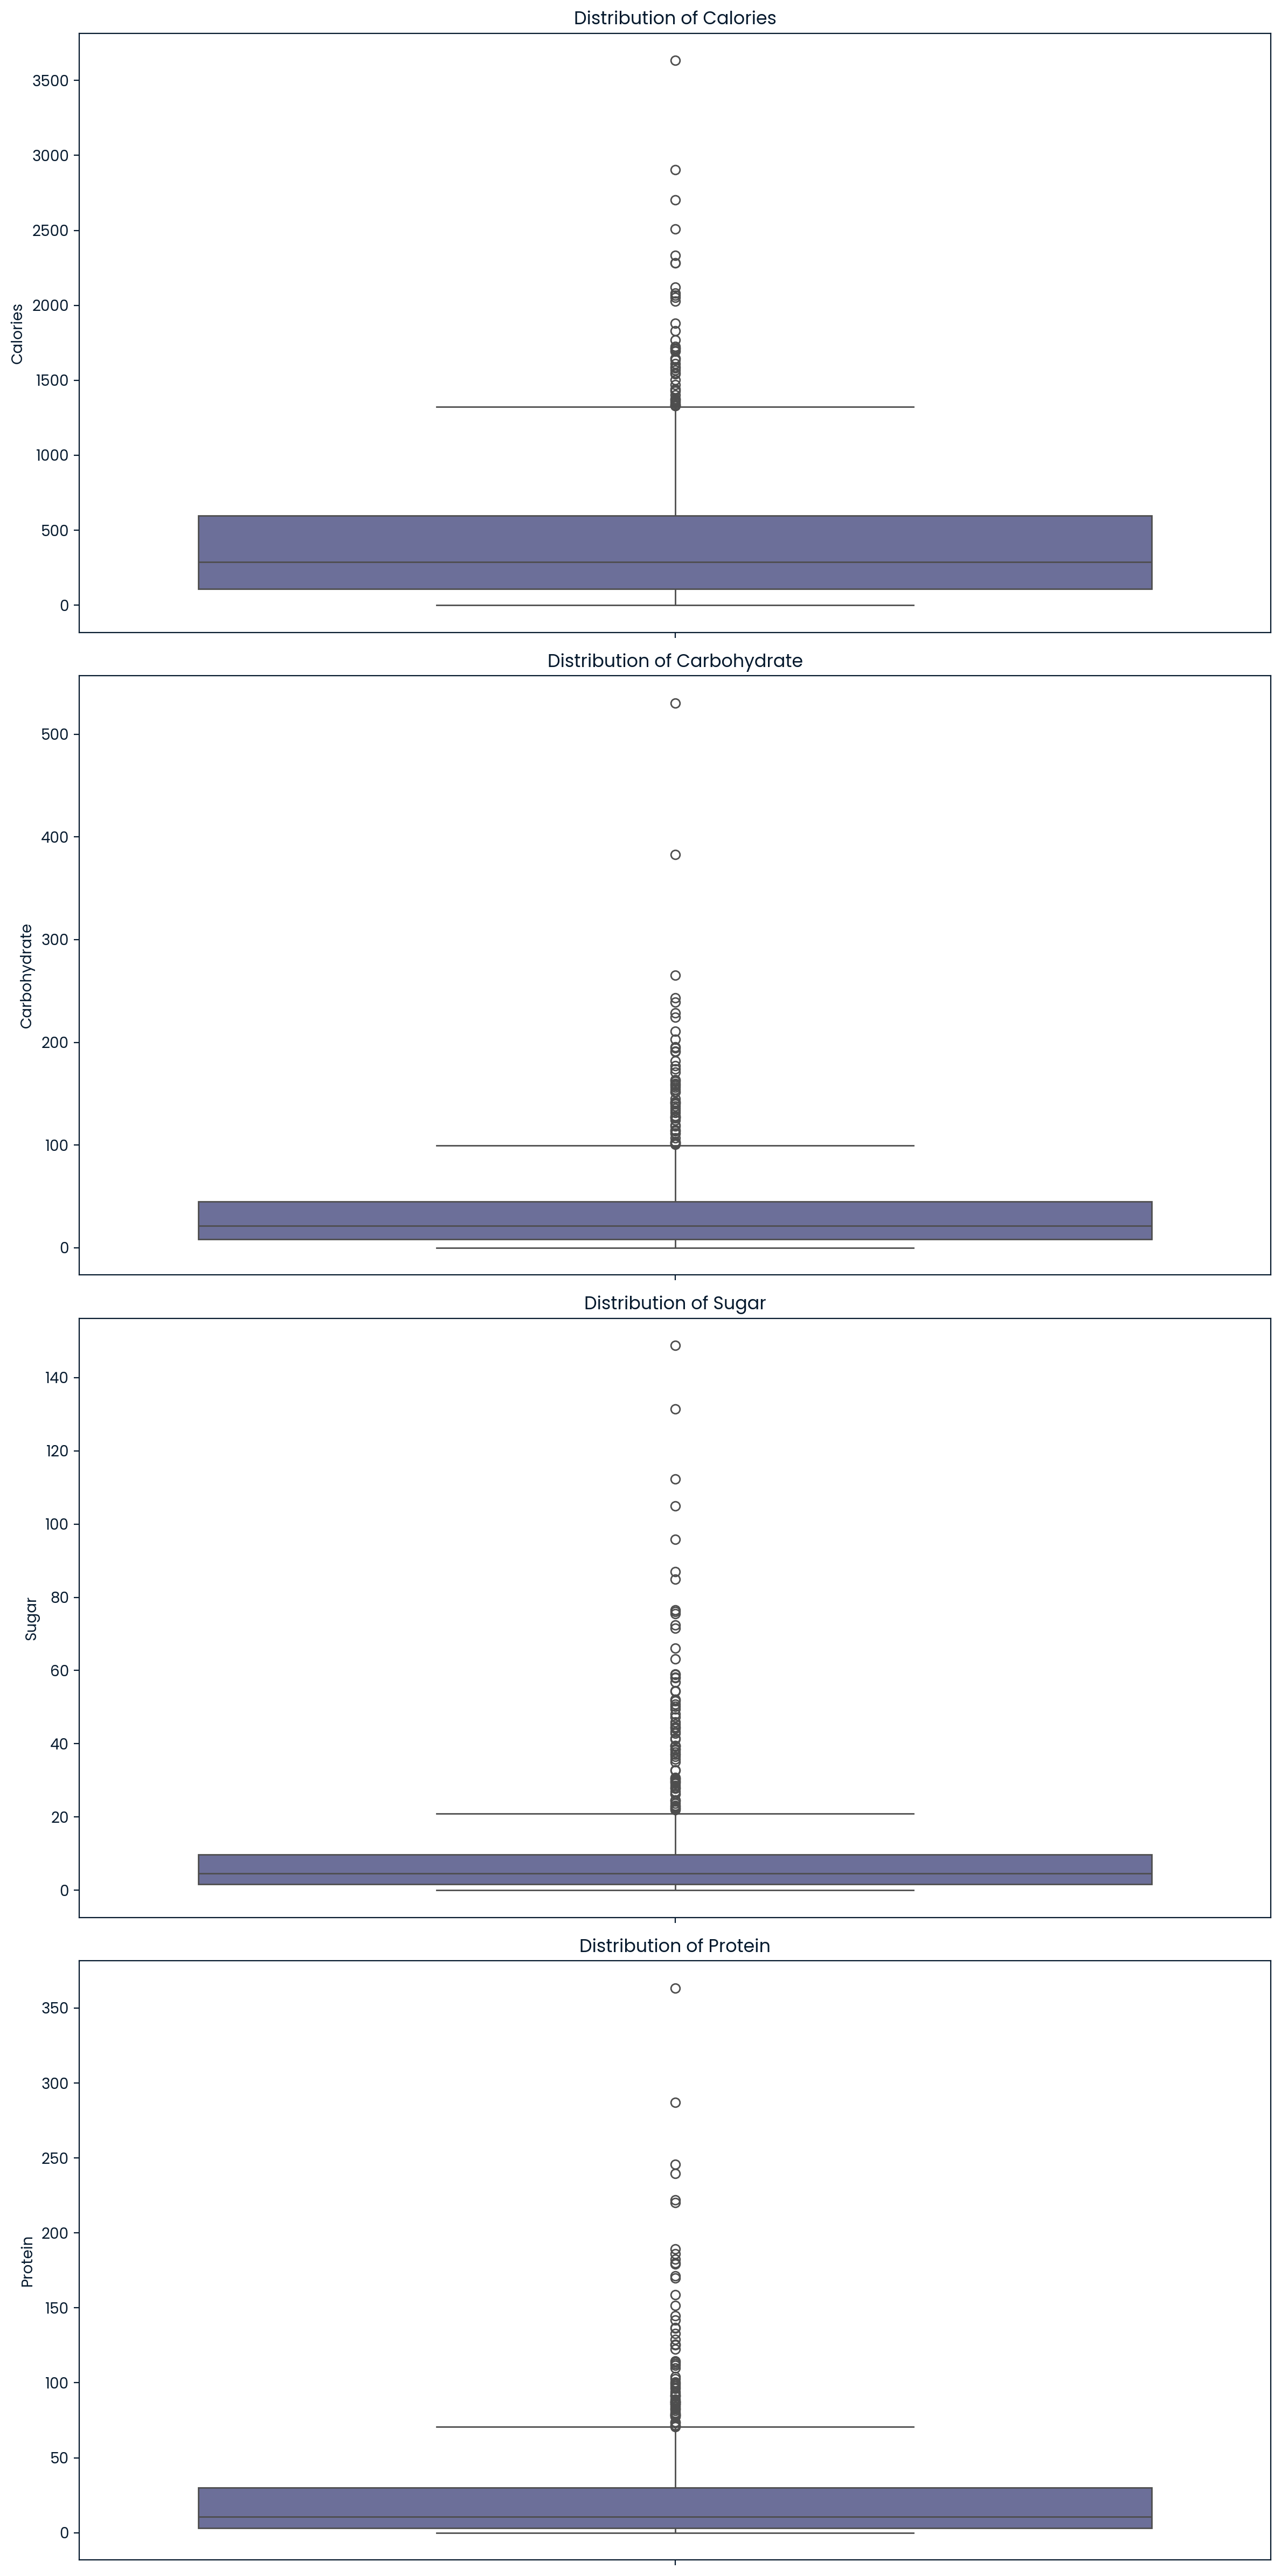

In [15]:
# Select only float columns
numerical_columns = df.select_dtypes(include=["float"]).columns
fig, axes = plt.subplots(nrows=len(numerical_columns),
                         ncols=1, figsize=(12, 6 * len(numerical_columns)))

# Ensure axes is iterable even if there's only one column
if len(numerical_columns) == 1:
    axes = [axes]
for ax, col in zip(axes, numerical_columns):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Distribution of {col.capitalize()}")
    ax.set_ylabel(col.capitalize())
fig.tight_layout()
plt.show()

### Boxplot Analysis of Nutritional Features

The boxplots for calories, carbohydrates, sugar, and protein show that the majority of values are clustered at the lower range, while a significant number of high outliers extend the distributions. This indicates that most recipes contain moderate levels of these nutrients, but a feww recipes with extremely high values create positive skewness and highlight the presence of outliers across all four nutritional components.

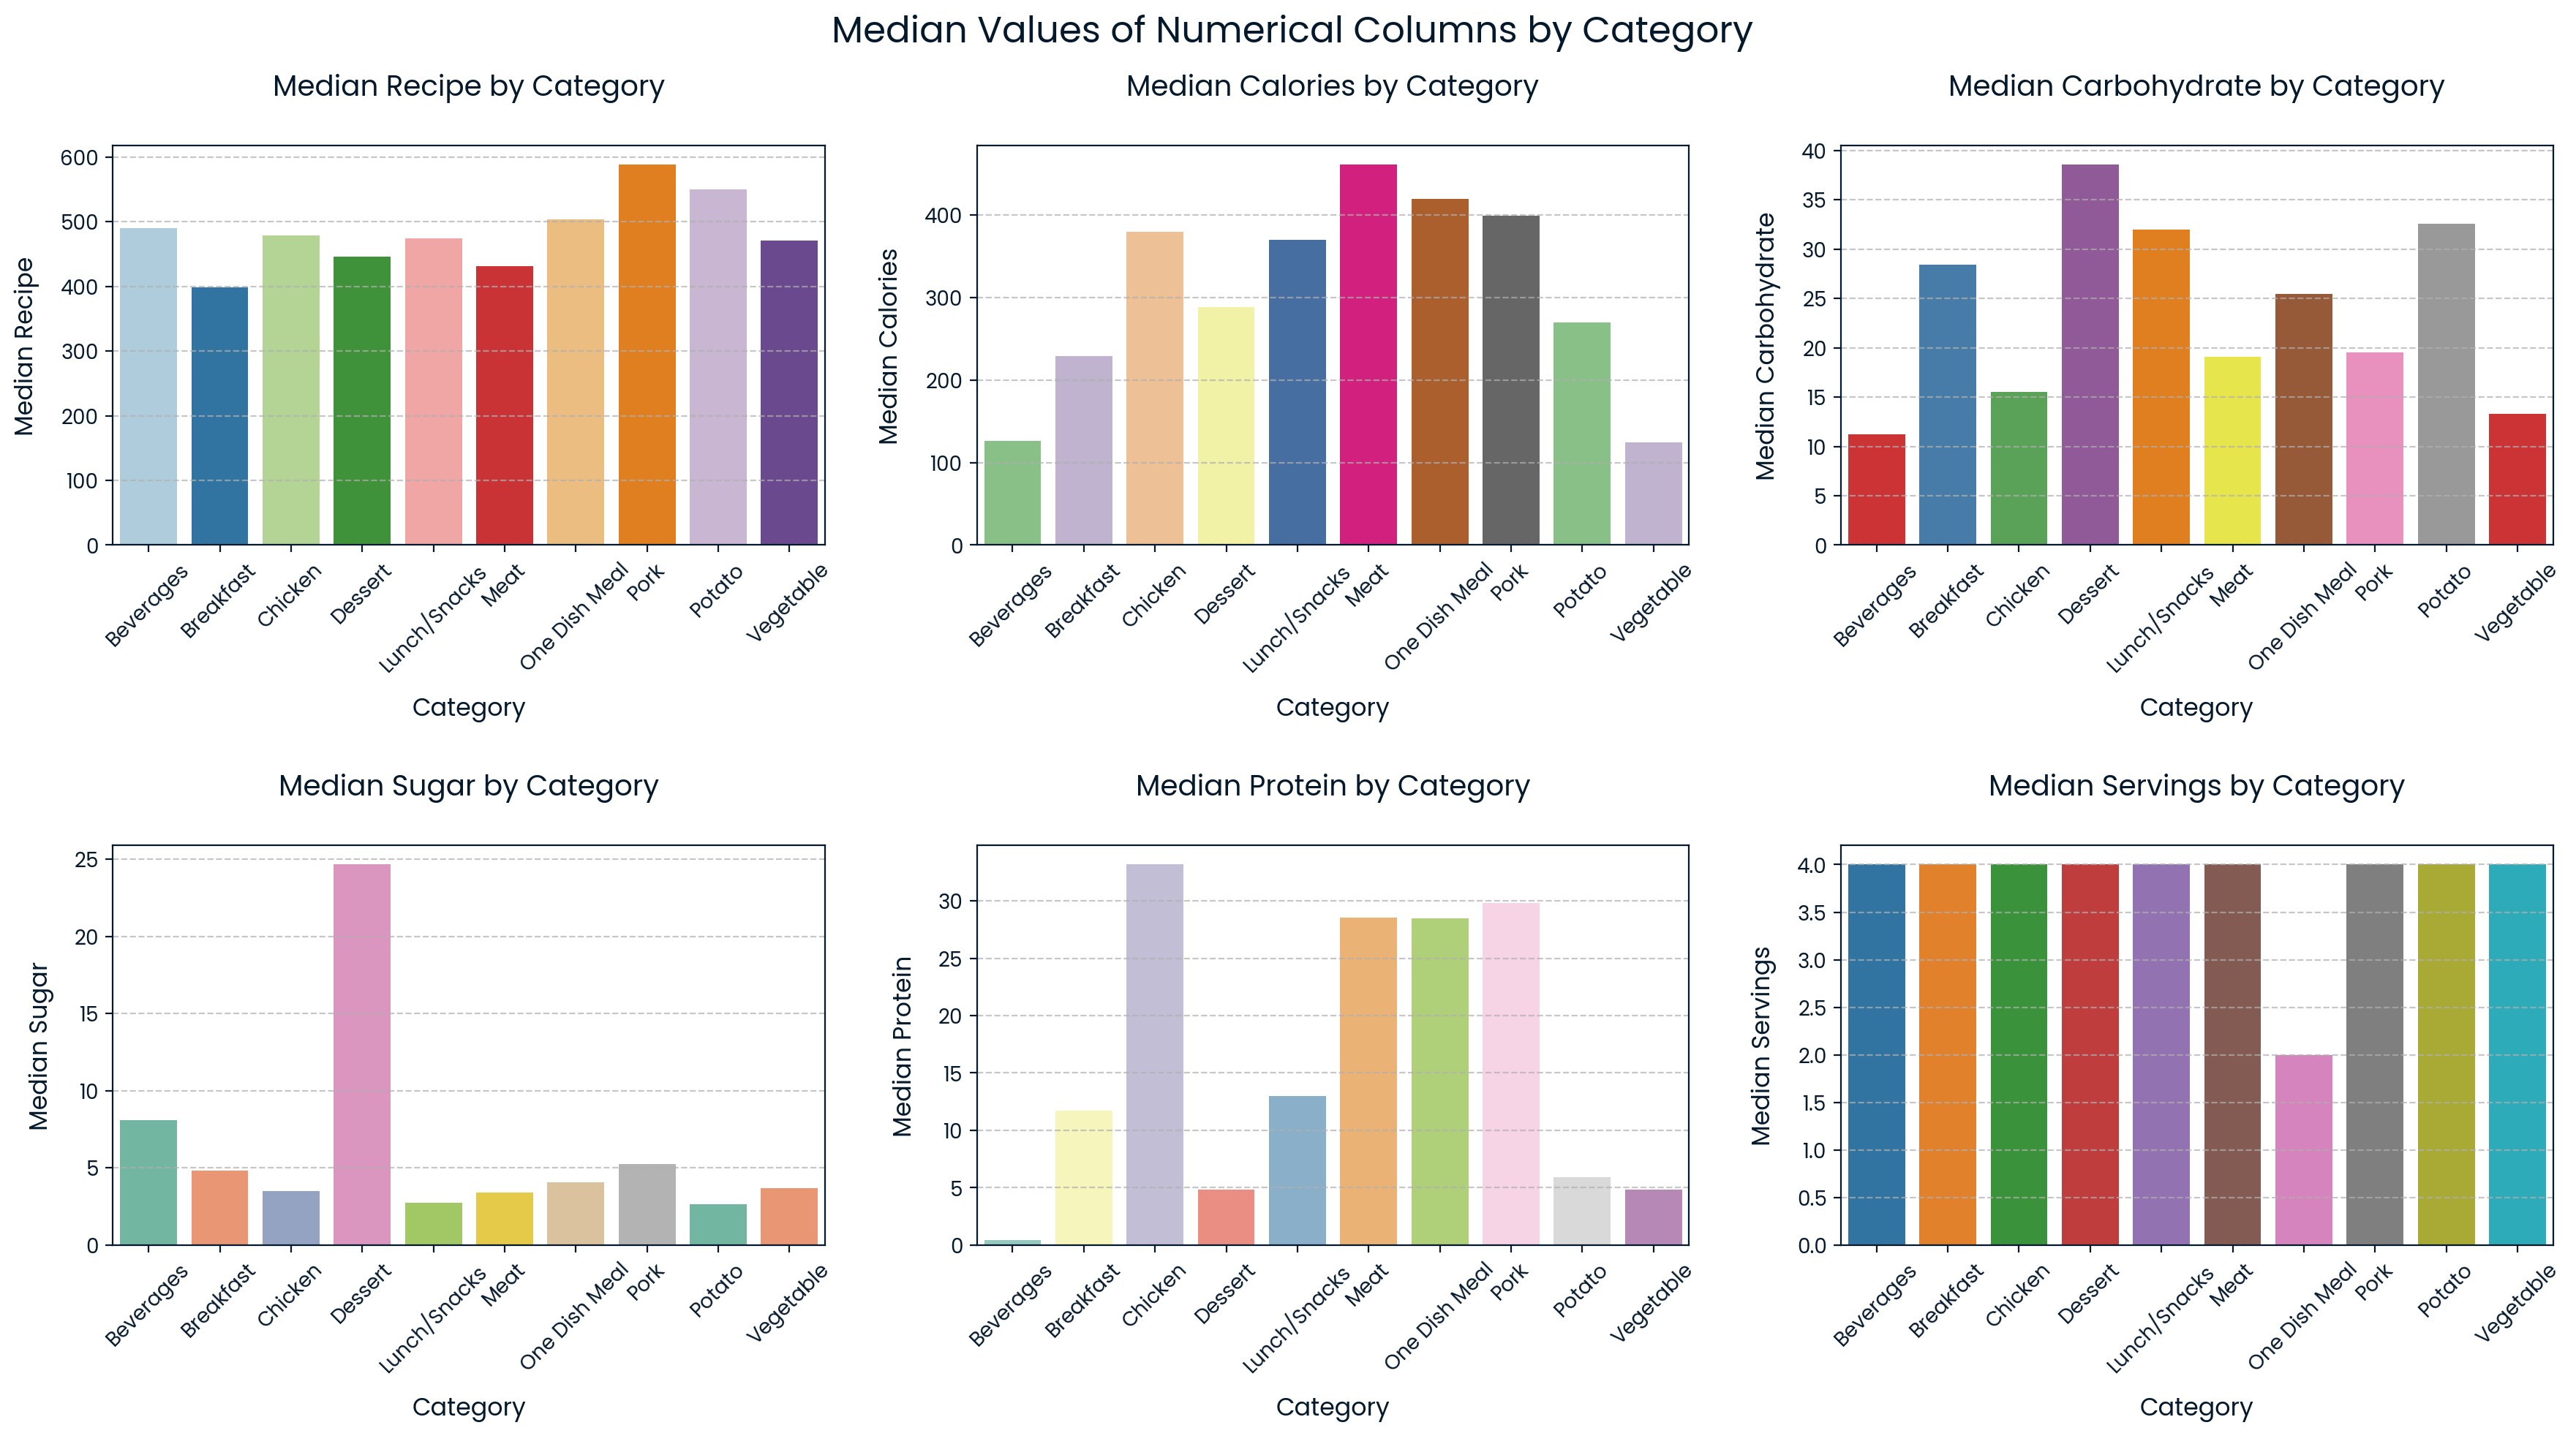

In [16]:
# Select numerical columns and compute median per category
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
category_medians = df.groupby("category")[numerical_columns].median().reset_index()

# Define color palettes
palettes = ["Paired", "Accent", "Set1", "Set2", "Set3",
            "tab10", "tab20", "tab20b", "tab20c", 
            "Pastel1", "Pastel2", "Dark2",
            "cubehelix", "rocket", "mako", "flare", "crest"]

# Auto grid size
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

# Plot each numerical column
for i, col in enumerate(numerical_columns):
    sns.barplot(
        x="category",
        y=col,
        data=category_medians,
        palette=palettes[i % len(palettes)],
        ax=axes[i]
    )
    axes[i].set_title(f"Median {col.capitalize()} by Category", fontsize=14, pad=25)
    axes[i].set_xlabel("Category", fontsize=12, labelpad=10)
    axes[i].set_ylabel(f"Median {col.capitalize()}", fontsize=12, labelpad=10)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

# Hide unused subplot axes
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout with padding
plt.tight_layout(pad=2.0, rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90)
fig.suptitle("Median Values of Numerical Columns by Category", fontsize=18, y=0.99)  # One big title
plt.show()

### Median Nutritional Values of Category

The bar plots highlight how nutritional values differ by recipe category. "One Dish Meal" and "Meat" stand out with higher median calories and protein, making them more energy and protein dense options. "Breakfast" and "Lunch/Snacks" show higher median carbohydrates, which aligns with their role as quick energy sources. "Dessert" clearly has the highest sugar content, while "Beverages" and "Vegetables" generally show the lowest median across most nutrients. These patterns give useful insights for dietary choices for examples, selecting vegetables for lighter meals or meat dishes for higher protein intake.

Overall, this supports earlier findings from histograms and boxplots: most recipes fall on the lower side of nutrient values, but some categories contribute more to the high outliers.

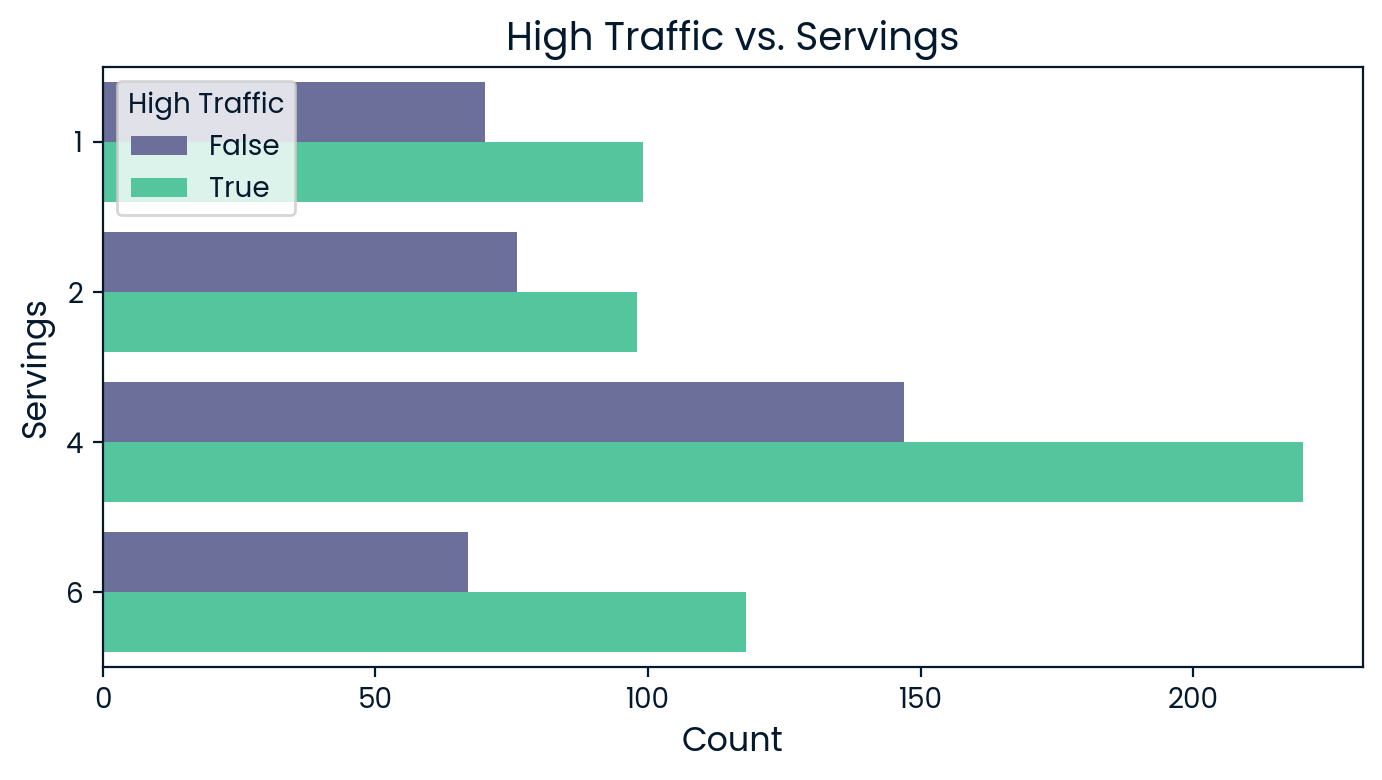

In [17]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df,
              y="servings",
              hue="high_traffic")

plt.title("High Traffic vs. Servings", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Servings", fontsize=12)
plt.legend(title="High Traffic", loc="upper left")
plt.tight_layout()
plt.show()

### Count Plot of Servings vs High Traffic 

The count plot illustrates how recipe servings relate to traffic levels, showing that some serving sizes occur more often than others while the color distinction reveals whether high-traffic recipes are concentrated in specific serving ranges, helping us see patterns in recipe popularity.

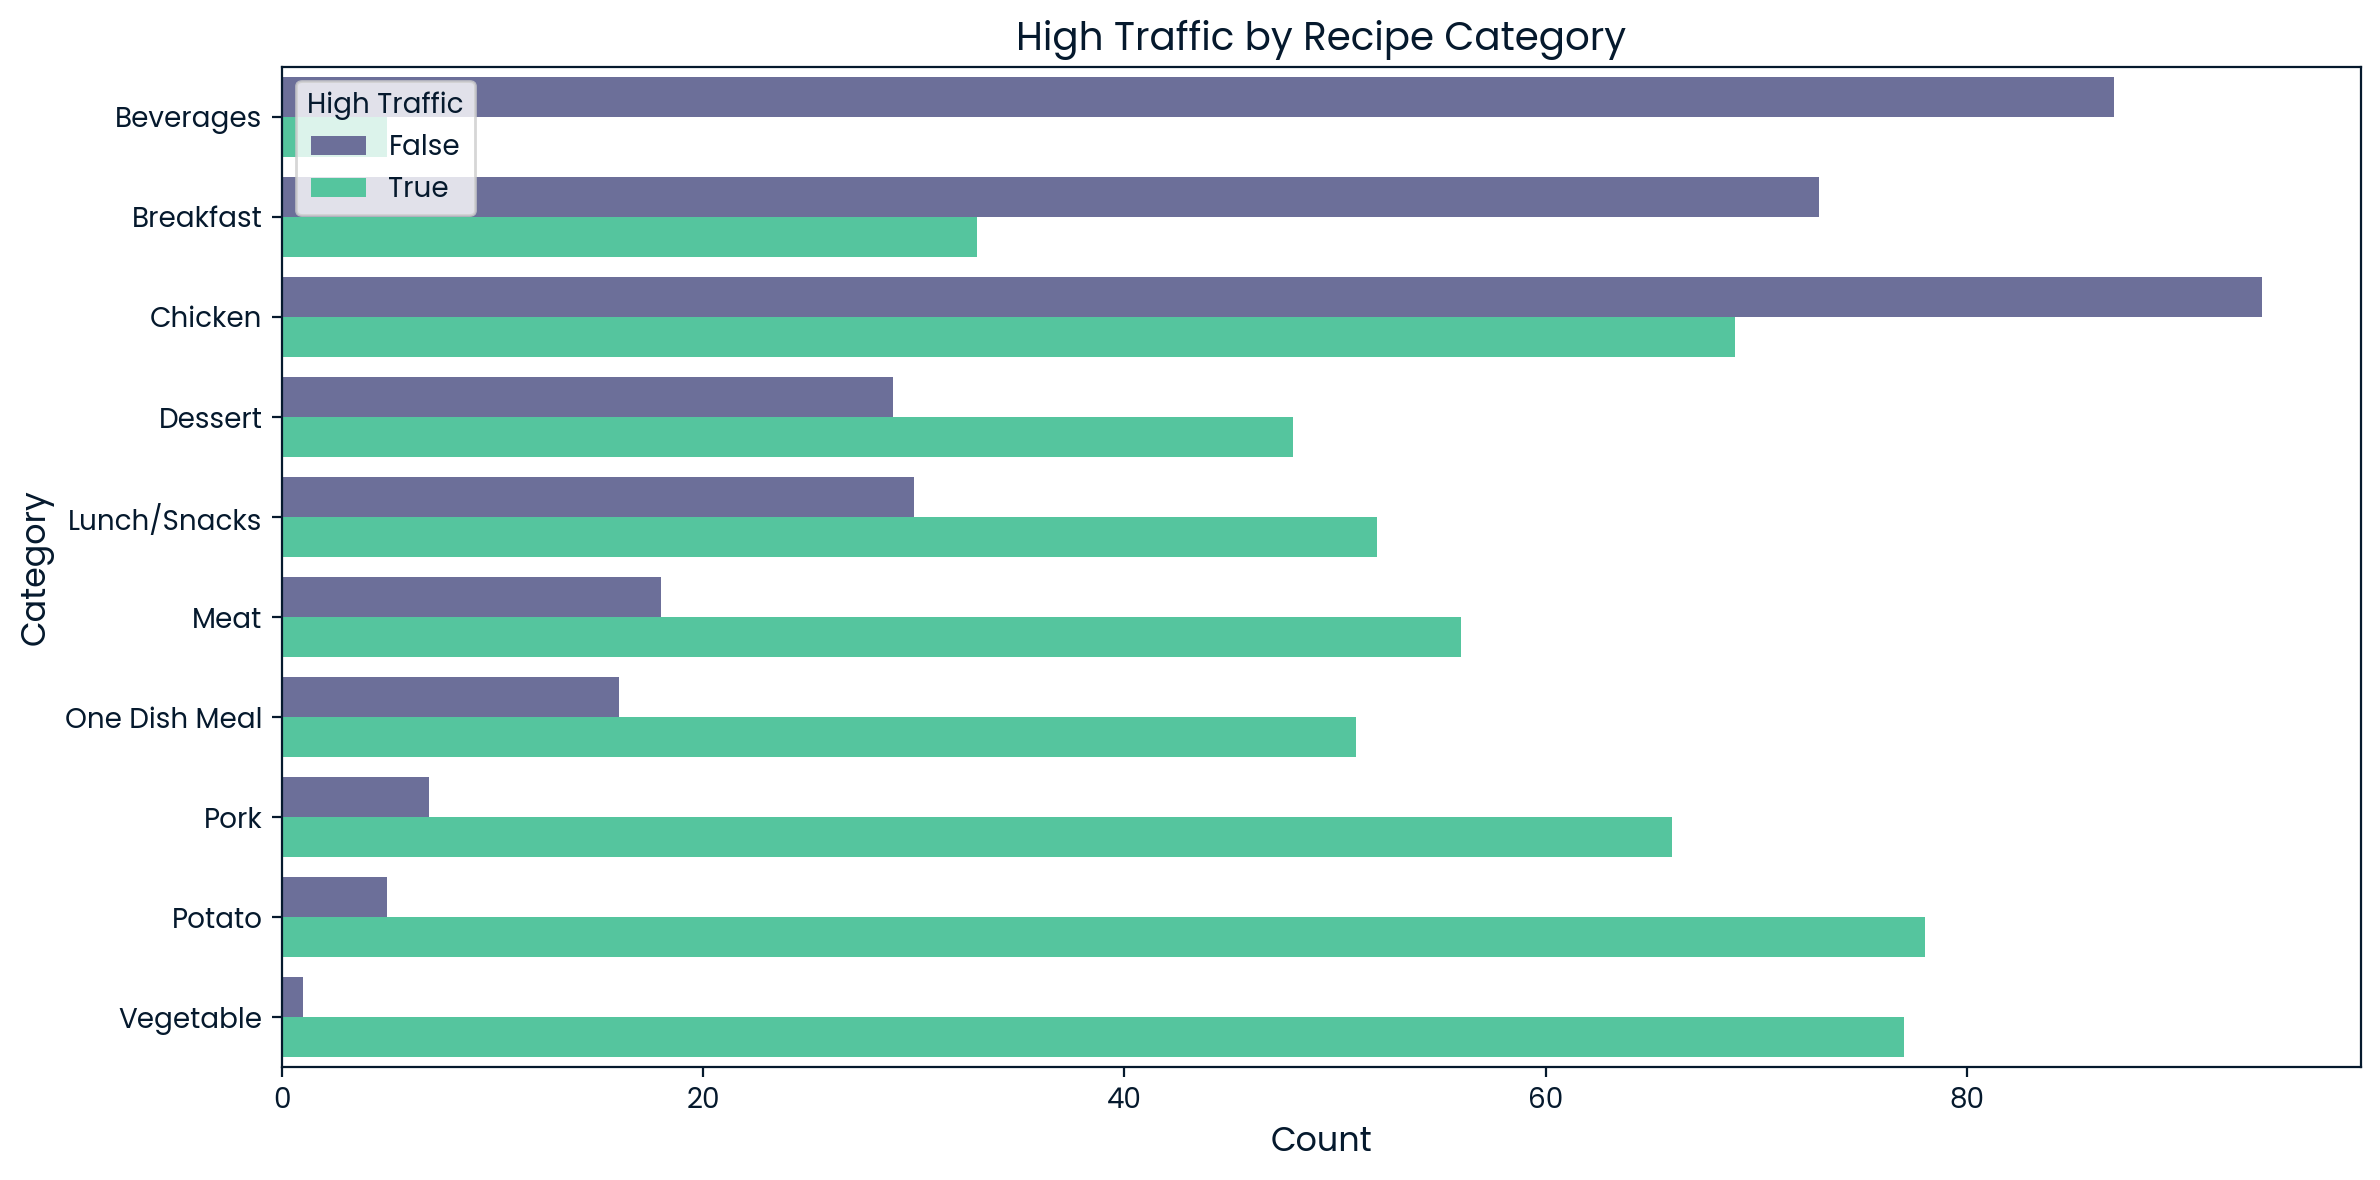

In [18]:
# Count plot each category to explore the relationship between the number of servings 
plt.figure(figsize=(12, 6))
sns.countplot(data=df,
              y="category",
              hue="high_traffic")

plt.title("High Traffic by Recipe Category", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.legend(title="High Traffic", loc="upper left")
plt.tight_layout()
plt.show()

### Count Plot of Categories vs High Traffic

This count plot shows how high-traffic recipes are distributed across different recipe categories. From the bars, we can identify which categories attract the most high-traffic recipes, as well as those with relatively low traffic. It also highlights whether high traffic is spread evenly across categories or concentrated in specific ones, giving insight into which recipe types are most popular.

In [19]:
# Create pivot table for aggregation
high_traffic_category = df.pivot_table(index="category",columns="high_traffic", values="recipe", aggfunc="count")
normalized_table = high_traffic_category.div(high_traffic_category.sum(axis=1), axis=0)
print(normalized_table.to_string())  # Used .to_string() for better console output

high_traffic      False     True 
category                         
Beverages      0.945652  0.054348
Breakfast      0.688679  0.311321
Chicken        0.576687  0.423313
Dessert        0.376623  0.623377
Lunch/Snacks   0.365854  0.634146
Meat           0.243243  0.756757
One Dish Meal  0.238806  0.761194
Pork           0.095890  0.904110
Potato         0.060241  0.939759
Vegetable      0.012821  0.987179


### Traffic Patterns and Modeling Approach

Certain categories drive more traffic; "Vegetables", "Potato", and "Pork" stand out as the top performers, while "Beverages" shows the lowest impact. To predict high traffic, I'll apply binary classification models including Logistic Regression, Decision Tree, Random Forest, SVM, and Gradient Boosting. Logistic Regression will serve as the baseline, and I'll handle outliers using Interquartile Range (IQR) method to establish upper and lower bounds before training the models.

In [20]:
def calculate_outlier_limits(df, factor=1.5):
    """Return lower and upper outlier boundaries using the IQR method."""
    q1, q3 = np.percentile(df, [25, 75])
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

numerical_columns = ["calories", "carbohydrate", "sugar", "protein"]

# Compute outlier limits for each column
outlier_limits = {col: calculate_outlier_limits(df[col])
for col in numerical_columns}

for col, (lower, upper) in outlier_limits.items():
    print(f"Outlier limits for {col}: Lower = {lower:.2f}, Upper = {upper:.2f}")

Outlier limits for calories: Lower = -620.40, Upper = 1328.48
Outlier limits for carbohydrate: Lower = -46.51, Upper = 99.85
Outlier limits for sugar: Lower = -10.48, Upper = 21.97
Outlier limits for protein: Lower = -37.31, Upper = 70.71


### Outlier Detection Using IQR

The outlier limits were calculated using the Interquartile Range (IQR) method with a factor of 1.5, giving thresholds to spot unusual values in the nutritional data.

- **Calories**: Any value below -620.40 or above 1328.48 is flagged as an outlier. Since negative calories aren't possible, the lower limit is effectively 0, so only values above 1328.48 are considered unusually high.
- **Carboohydrate**: Values below -46.51 or above 99.85 are considered outliers. The practical lower limit is 0, and values exceeding 99.85 indicate very high carbohydrate content.
- **Sugar**: Outliers fall below -10.48 or above 21.97. With sugar values not going negative, the lower limit is 0, and values greater than 21.97 highlight recipes wiwth high sugar.
- **Protein**: Outliers are those below -37.31 or above 70.71. Again, the lower limit is 0, so values above 70.71 represent recipes with exceptionally high protein.

In [21]:
# Select only float columns
numerical_columns = df.select_dtypes(include='float').columns
transformed_data = df.copy()  # Copy dataset

# Apply Yeo-Johnson transformation to each numeric column
for col, (lower_limit, upper_limit) in outlier_limits.items():
    transformed_data[col] = yeojohnson(transformed_data[col])[0]

print(transformed_data.head())

   recipe   calories  carbohydrate  ...       category  servings high_traffic
0       2   5.742713      4.409023  ...         Potato         4         True
1       3  17.437755      4.550612  ...      Breakfast         1        False
2       4   8.416476      4.091120  ...      Beverages         4         True
3       5   5.133412      1.101661  ...      Beverages         4        False
4       6  16.024490      1.607528  ...  One Dish Meal         2         True

[5 rows x 8 columns]


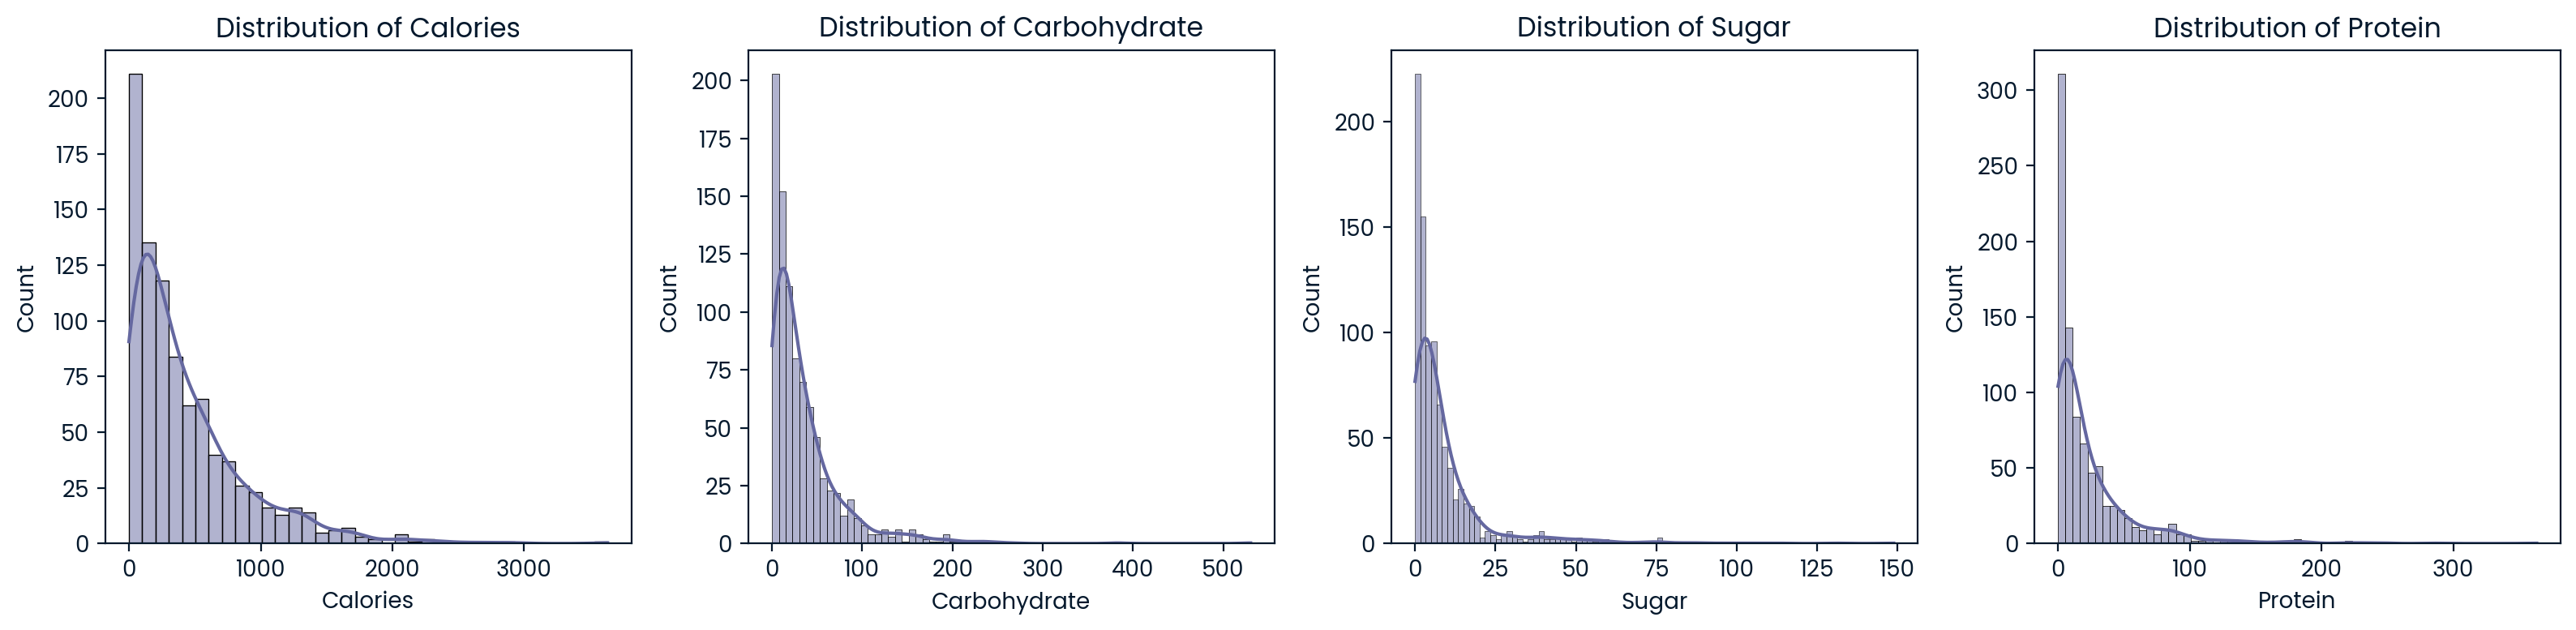

In [22]:
# Visualize distributions of transformed numerical columns
fig, axes = plt.subplots(nrows=1,
                         ncols=len(numerical_columns), figsize=(16, 4))

for ax, col in zip(axes, numerical_columns):
    sns.histplot(data=df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Nutritional Distribution

The histograms for Calories, Carbohydrate, Sugar, and Protein reveal strongly right-skewed distributions. Most values are clustered at the lower end, while a smaller portion of recipes extends far to the right with much higher nutrient values. This pattern suggests that the majority of recipes are relatively low in these nutrients, but a few contain exceptionally high amounts that pull the distributions toward the right.

In [23]:
# Perform one-hot encode to category column with strict binary 0/1 output
data_encoded = pd.get_dummies(transformed_data, columns=["category"], prefix="category", dtype=int)
data_encoded.head()

,recipe,calories,carbohydrate,sugar,protein,servings,high_traffic,category_Beverages,category_Breakfast,category_Chicken,category_Dessert,category_Lunch/Snacks,category_Meat,category_One Dish Meal,category_Pork,category_Potato,category_Vegetable
0,2,5.742713,4.409023,0.481476,0.653469,4,True,0,0,0,0,0,0,0,0,1,0
1,3,17.437755,4.550612,1.224094,1.360783,1,False,0,1,0,0,0,0,0,0,0,0
2,4,8.416476,4.091120,2.587147,0.019804,4,True,1,0,0,0,0,0,0,0,0,0
3,5,5.133412,1.101661,0.553884,0.425754,4,False,1,0,0,0,0,0,0,0,0,0
4,6,16.024490,1.607528,0.883720,4.049462,2,True,0,0,0,0,0,0,1,0,0,0


## Model Fitting & Evaluation

In [24]:
# Model Development
X = data_encoded.drop("high_traffic", axis=1)
y = data_encoded["high_traffic"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def develop_model(model, X_train, y_train, X_test, y_test):
    """
    Train a model and evaluate it on training and testing sets.
    Returns accuracy, precision, recall, f1-score, and confusion matrix.
    """
    results = {}

    # Fit model
    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Training metrics
    results["train"] = {
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "confusion_matrix": confusion_matrix(y_train, y_pred_train),
    }

    # Testing metrics
    results["test"] = {
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test),
        "recall": recall_score(y_test, y_pred_test),
        "f1": f1_score(y_test, y_pred_test),
        "confusion_matrix": confusion_matrix(y_test, y_pred_test),
    }

    return results

def print_metrics(metrics):
    """Print evaluation metrics."""
    print(f" Accuracy: {metrics['accuracy']}")
    print(f" Precision: {metrics['precision']}")
    print(f" Recall: {metrics['recall']}")
    print(f" F1-Score: {metrics['f1']}")
    print(" Confusion Matrix:")
    print(metrics["confusion_matrix"])
    print("-" * 40)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}    

In [25]:
# Model Evaluation
for name, model in models.items():
    print(f"\n{name} Results:")
    results = develop_model(model, X_train, y_train, X_test, y_test)

    print(" Train Performance:")
    print_metrics(results["train"])

    print(" Test Performance:")
    print_metrics(results["test"])


Logistic Regression Results:
 Train Performance:
 Accuracy: 0.7541899441340782
 Precision: 0.7720430107526882
 Recall: 0.8368298368298368
 F1-Score: 0.8031319910514543
 Confusion Matrix:
[[181 106]
 [ 70 359]]
----------------------------------------
 Test Performance:
 Accuracy: 0.7486033519553073
 Precision: 0.7520661157024794
 Recall: 0.8584905660377359
 F1-Score: 0.801762114537445
 Confusion Matrix:
[[43 30]
 [15 91]]
----------------------------------------

Decision Tree Results:
 Train Performance:
 Accuracy: 1.0
 Precision: 1.0
 Recall: 1.0
 F1-Score: 1.0
 Confusion Matrix:
[[287   0]
 [  0 429]]
----------------------------------------
 Test Performance:
 Accuracy: 0.6201117318435754
 Precision: 0.6759259259259259
 Recall: 0.6886792452830188
 F1-Score: 0.6822429906542056
 Confusion Matrix:
[[38 35]
 [33 73]]
----------------------------------------

Random Forest Results:
 Train Performance:
 Accuracy: 1.0
 Precision: 1.0
 Recall: 1.0
 F1-Score: 1.0
 Confusion Matrix:
[[287  

### Model Evaluation Summary
- **Logistic Regression**: Performs consistently with 74-76% accuracy and 80% F1 on both train and test. It generalizes well without major overfitting.
- **Decision Tree**: Perfect scores on training (100% across all metrics) but drops to 62% accuracy and 68% F1 on test, showing clear overfitting.
- **Random Forest**: Also overfits (100% on training) but performs a bit better than Decision Tree on test (70% accuracy, 76% F1).
- **SVC**: Weak results (59% accuracy). It predicts mostly the positive class, which leads to recall = 1.0 but poor precision.
- **Gradient Boosting**: Strong performance overall (87% train accuracy, 70% test accuracy, 76% F1). It handles overfitting better than Decision Tree/Random Forest while keeping solid predictive power.

**Takeaway**: Logistic Regression remains the most consistent choice. Gradient Boosting is also a strong alternative, while Decision Tree and Random Forest suffer from overfitting. SVC is the least effective on this dataset. 

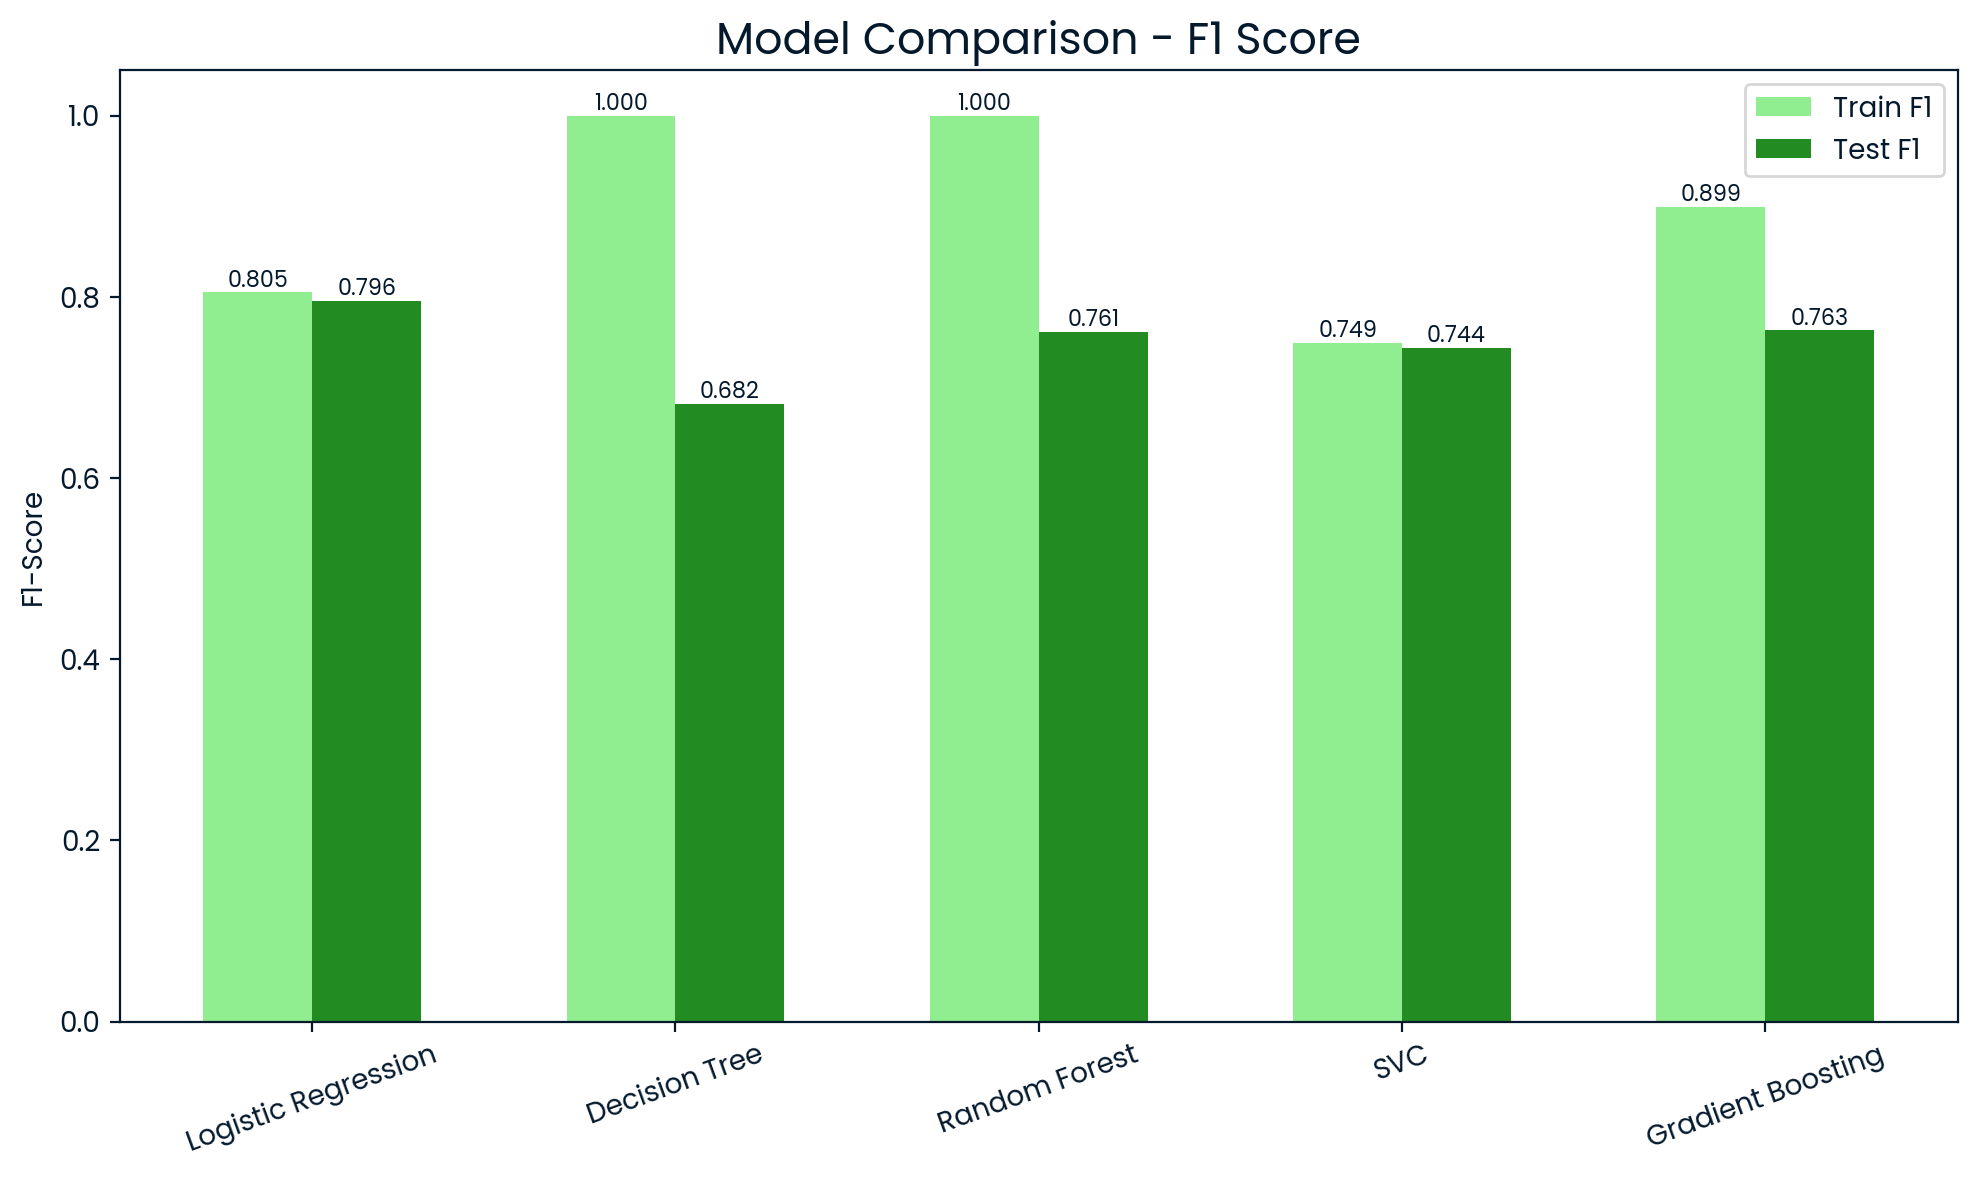

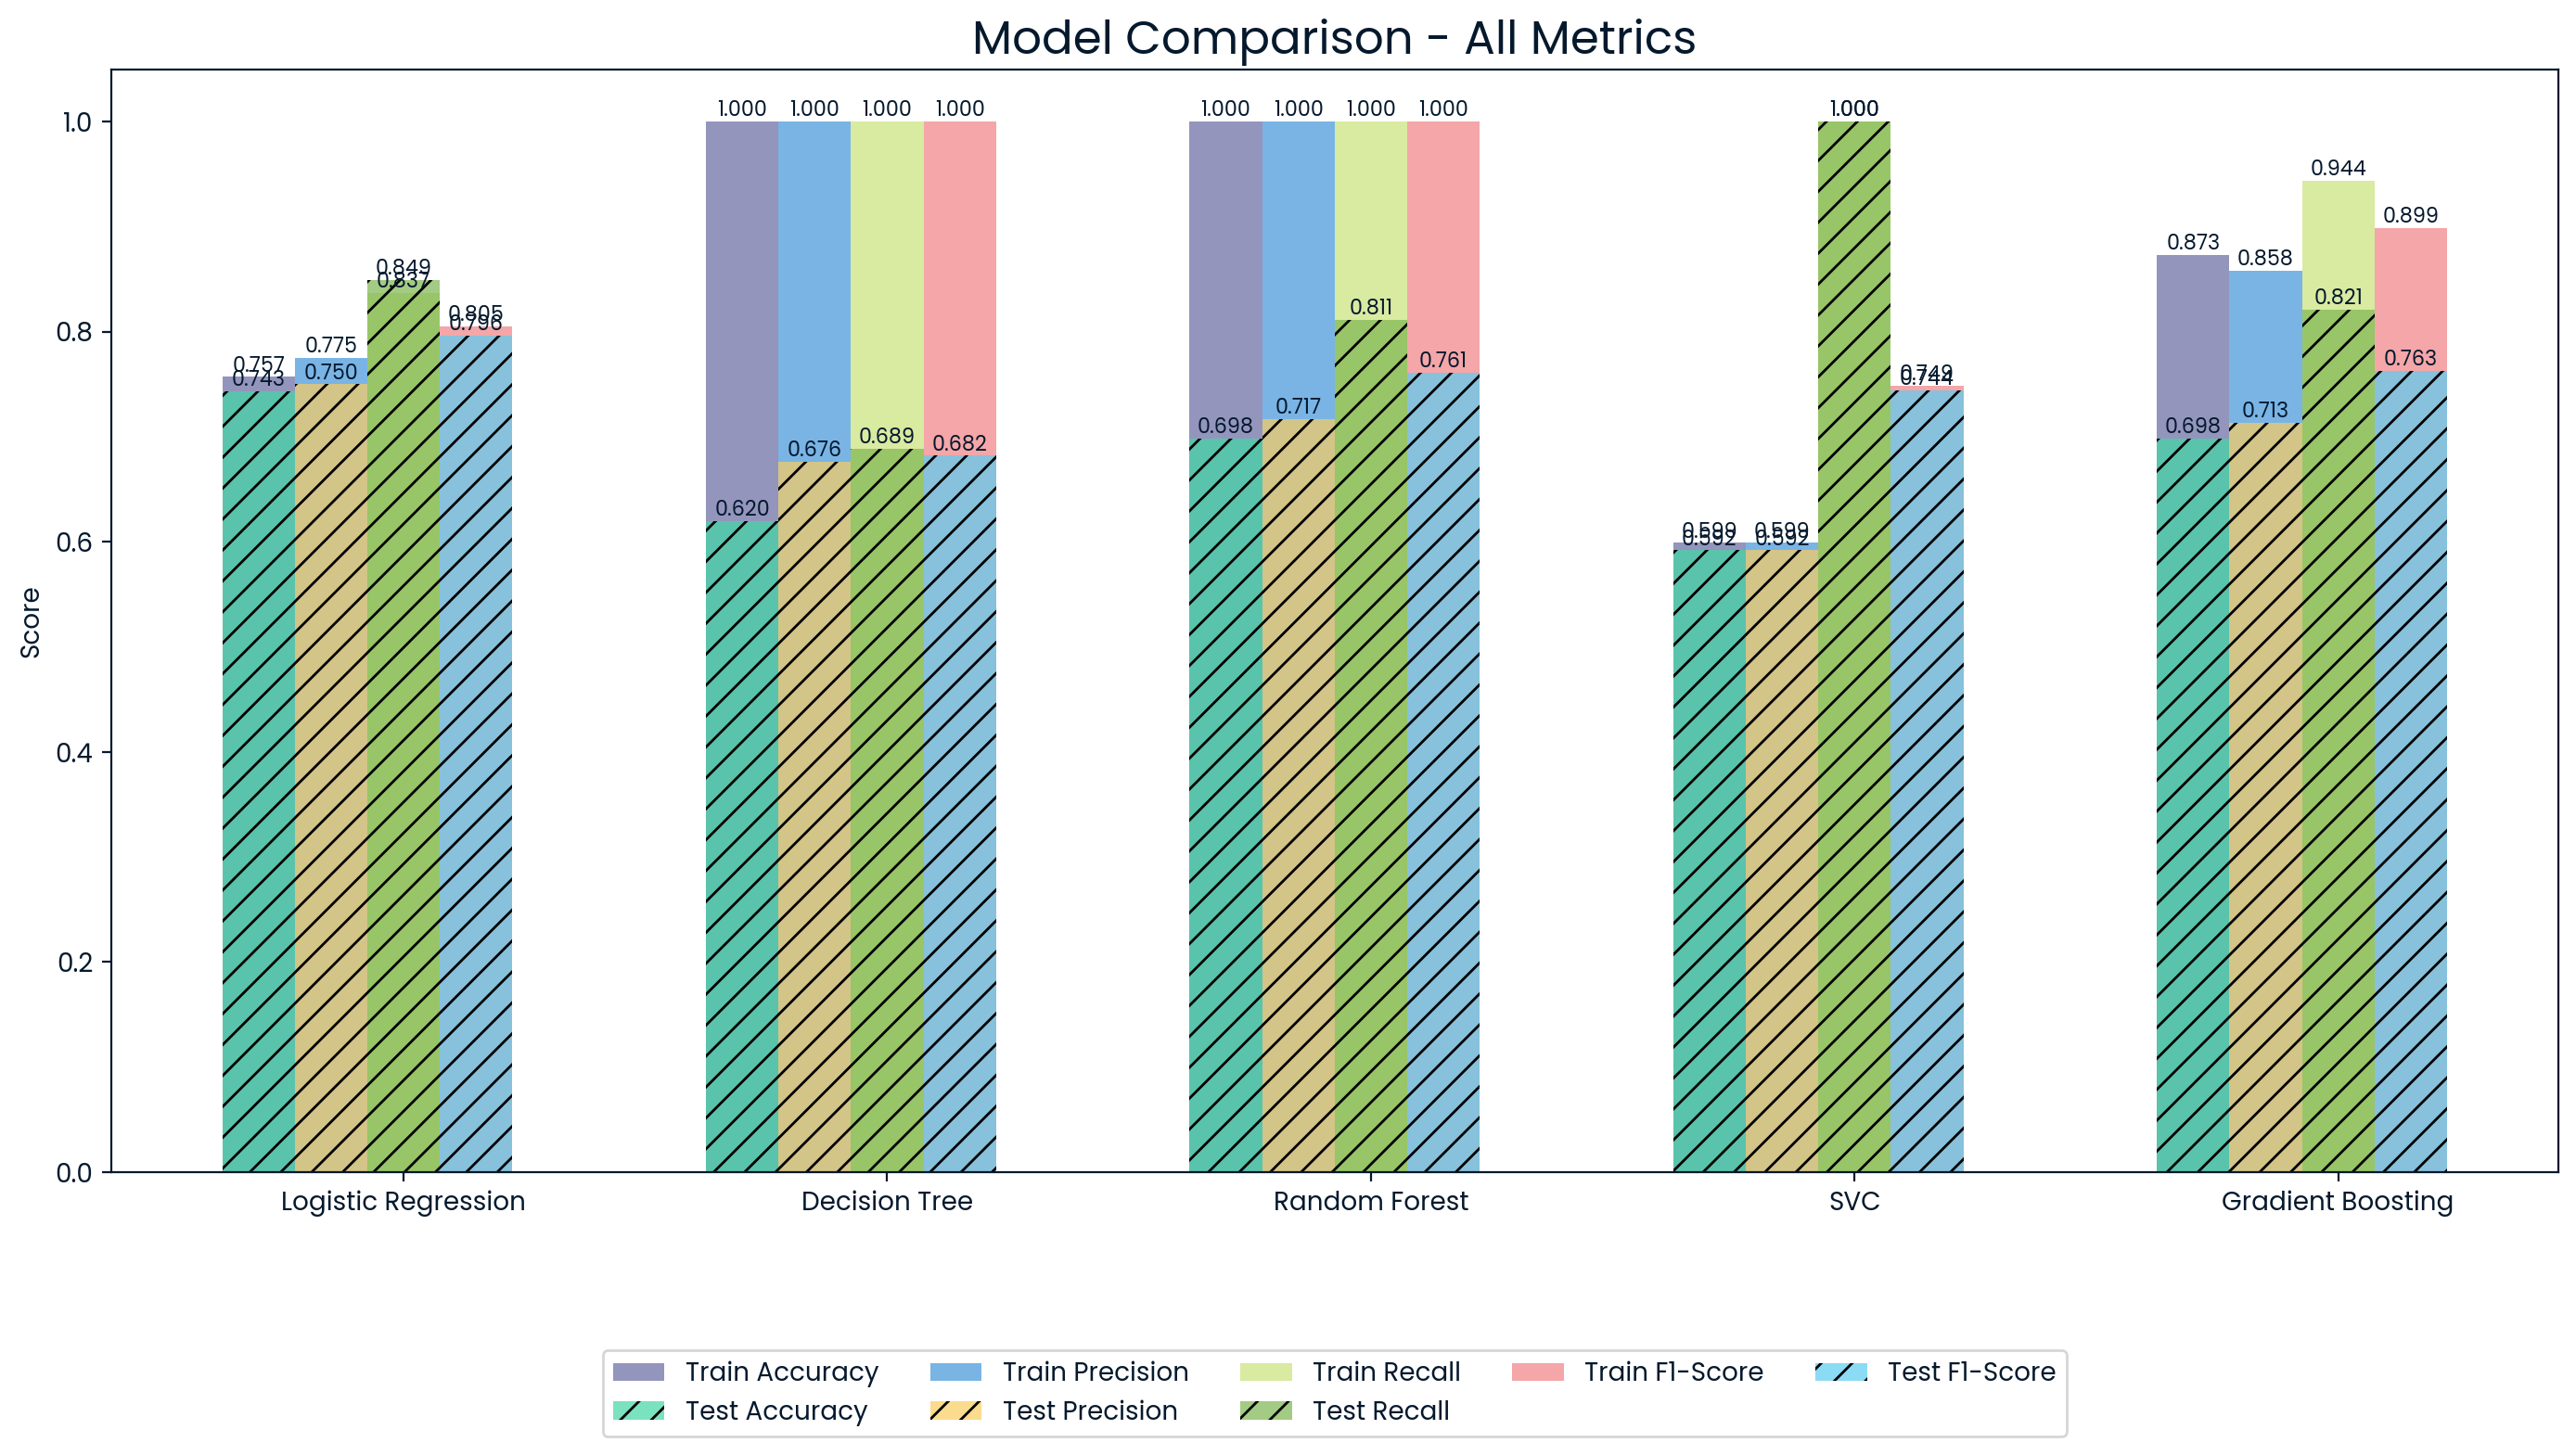

In [26]:
# Model results
results = {
    "Logistic Regression": {
        "train": {"Accuracy": 0.757, "Precision": 0.775, "Recall": 0.837, "F1-Score": 0.805},
        "test":{"Accuracy": 0.743, "Precision": 0.750, "Recall": 0.849, "F1-Score": 0.796}
    },
    "Decision Tree": {
        "train": {"Accuracy": 1.000, "Precision": 1.000, "Recall": 1.000, "F1-Score": 1.000},
        "test": {"Accuracy": 0.620, "Precision": 0.676, "Recall": 0.689, "F1-Score": 0.682}
    },
    "Random Forest": {
        "train": {"Accuracy": 1.000, "Precision": 1.000, "Recall": 1.000, "F1-Score": 1.000},
        "test": {"Accuracy": 0.698, "Precision": 0.717, "Recall": 0.811, "F1-Score": 0.761}
    },
    "SVC": {
        "train": {"Accuracy": 0.599, "Precision": 0.599, "Recall": 1.000, "F1-Score": 0.749},
        "test": {"Accuracy": 0.592, "Precision": 0.592, "Recall": 1.000, "F1-Score": 0.744}
    },
    "Gradient Boosting": {
        "train": {"Accuracy": 0.873, "Precision": 0.858, "Recall": 0.944, "F1-Score": 0.899},
        "test": {"Accuracy": 0.698, "Precision": 0.713, "Recall": 0.821, "F1-Score": 0.763}
    },
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
models = list(results.keys())

# quick function to label bars
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

# F1-Score bar plot
x = np.arange(len(models))  # the label locations
bar_width = 0.30  # the width of the bars

train_f1 = [results[m]["train"]["F1-Score"] for m in models]
test_f1 = [results[m]["test"]["F1-Score"] for m in models]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - bar_width / 2, train_f1, bar_width, label="Train F1", color="lightgreen")
bars2 = ax.bar(x + bar_width / 2, test_f1, bar_width, label="Test F1", color="forestgreen")

ax.set_ylabel("F1-Score")
ax.set_title("Model Comparison - F1 Score", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.legend()

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

# All metrics bar plot
x = np.arange(len(models))  # the label locations
bar_width = 0.15   # the width of the bars

fig, ax = plt.subplots(figsize=(14, 8))

for i, metric in enumerate(metrics):
    train_vals = [results[m]["train"][metric] for m in models]
    test_vals = [results[m]["test"][metric] for m in models]
    offset = bar_width * (i - len(metrics) / 2)

    b1 = ax.bar(x + offset, train_vals, bar_width, alpha=0.7, label=f"Train {metric}")
    b2 = ax.bar(x + offset, test_vals, bar_width, alpha=0.7, hatch="//", label=f"Test {metric}")

    add_labels(b1)
    add_labels(b2)

ax.set_ylabel("Score")
ax.set_title("Model Comparison - All Metrics", fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), fancybox=True, ncol=5)

plt.tight_layout()
plt.show()

## Business Metrics

Defining clear business metrics is essential to quantify the real-world impact of **predicting "high-traffic" recipes**. In this context, high traffic equates to greater visibility, increased website visits, more ad impressions, and ultimately, enhanced revenue opportunities. The machine learning models we employ—**Logistic Regression**, **Decision Tree**, **Random Forest**, **SVM**, and **Gradient Boosting**—are not just technical tools; they are strategic assets for identifying recipes most likely to drive significant user engagement.

For instance, suppose a model predicts 100 recipes as high-traffic, and these recipes collectively generate 85,000 views. If a baseline approach, such as randomly promoting recipes, yields only 50,000 views, the data-driven strategy results in a 70% increase in website traffic. This uplift directly translates to higher ad revenue, more user interactions, and increased opportunities for conversions (e.g., ad clicks, subscriptions, or recipe saves).

Beyond just increasing views, these predictive models enable smarter resource allocation. Instead of distributing marketing budgets evenly across all recipes, resources can be concentrated on those with the highest predicted return, maximizing the impact of every dollar spent. This targeted approach not only improves traditional model performance metrics like precision and recall, but also drives tangible **business growth**, delivers a stronger **ROI**, and supports more **strategic decision-making**.

In summary, leveraging predictive models for recipe selection transforms data insights into measurable business value, ensuring that marketing and operational efforts are both efficient and effective.

## Final Summary and Business Recommendations

### Summary

Among the five models tested, Logistic Regression stands out as the most reliable for predicting high-traffic recipes, showing strong generalization without severe overfitting. Other models display issues such as overfitting, poor generalization, or instability, making them less suitable in their current form.

- **Logistic Regression**: Performs consistently acriss train and test sets with balanced accuracy and F1-Score, making it the most promising model for deployment.
- **Decision Tree**: Shows extreme overfitting (perfect scores on training but weak test performance), requiring techniques like pruning or depth limitation to improve.
- **Random Forest**: Also overfits, though less severely than the Decision Tree. Tuning parameters such as tree depth or number of estimators could improve results.
- **SVM**: Predicts almost all cases as positive, achieving perfect recall but low precision. Likely caused by class imbalance, lack of feature scaling, or suboptimal kernel choice. Requires preprocessing and hyperparameter tuning.
- **Gradient Boosting**: Delivers solid test performance and avoids severe overfitting, but slightly lags behind Logistic Regression in stability and consistency, making it a strong alternative if further tuning is applied.

### Recommendations



Based on the evaluation of the five models, I recommend the following approach for predicting high-traffic recipes:

- Prioritize **Logistic Regression** for Deployment:
Logistic Regression stands out as the most reliable model for immediate deployment. It demonstrates strong generalization capabilities with balanced accuracy and F1-scores across both training and test sets. Its consistent performance and resistance to overfitting make it well-suited for production use without the need for extensive tuning.

- Consider Gradient Boosting as a Strong Alternative:
Gradient Boosting also shows solid performance on the test data and avoids the overfitting issues seen in other tree-based models. With further hyperparameter tuning, it has the potential to rival or even surpass Logistic Regression. This makes it a strong candidate as a secondary or backup model.

- Refine Tree-Based Models (Decision Tree & Random Forest):
Both Decision Tree and Random Forest models exhibit signs of overfitting, performing well on training data but falling short on generalization. To address this, I recommend applying regularization techniques—such as pruning, limiting tree depth, or reducing the number of estimators—to improve their ability to handle unseen data.

- Revisit the SVM Model:
The SVM model appears to be overly biased toward predicting positive cases, which may be due to class imbalance, improper feature scaling, or suboptimal kernel selection. Before considering SVM for production, it's important to address these issues through targeted preprocessing, dataset balancing, and hyperparameter optimization.

- Implement Ongoing Monitoring and Maintenance:
Regardless of the model selected, continuous monitoring in a production environment is essential. As new data becomes available, the model should be periodically retrained or fine-tuned to ensure it maintains high predictive accuracy over time.

In summary, I recommend deploying **Logistic Regression** as the primary model, with Gradient Boosting as a promising alternative. Meanwhile, efforts should focus on improving the generalization performance of the remaining models through careful tuning and preprocessing.